# Optical Computing Publications Over Time (OpenAlex)

This notebook queries the OpenAlex Works API to estimate yearly publication counts for a set of optical computing phrases.

It:
- searches from 1970 to the present year
- searches **title OR abstract**
- applies **exclusion terms**
- saves results to CSV
- plots raw yearly counts and an optional rolling average

You can edit the include and exclusion term lists in the configuration cell.


In [15]:
import time
from datetime import datetime
import random
import matplotlib.pyplot as plt
import pandas as pd
import requests

BASE_URL = None
EMAIL = None # replace with your email
API_KEY = 'h6lXEhOKUo7SvkfHF1boWX' # optional; set to your OpenAlex API key if you have one


In [4]:
# =========================
# Configuration
# =========================

START_YEAR = 1975
END_YEAR = 2025

INCLUDE_TERMS = [
    # General / modern
    "optical computing",
    "photonic computing",
    "silicon photonic processing",
    "integrated photonic processing",

    # Historical
    "optical information processing",
    "optical signal processing",
    "photonic information processing",
    "analog optical computing",
    "free-space optical computing",
    "optoelectronic computing",

    # Architectures / functions
    "optical matrix multiplication",
    "optical correlator",
    "optical pattern recognition",

    # AI / neural
    "optical neural network",
    "photonic neural network",
    "silicon photonic neural network",
    "optical perceptron",
    "photonic reservoir computing",
    "neuromorphic photonics",

    # Modern AI phrasing
    "optical artificial intelligence",
]


# Exclusion terms
EXCLUDE_TERMS = [
    # "fiber optic communication",
    # "optical communications",
    # "optical interconnect",
    # "fiber-optic sensor",
    # "optical storage",
    # "laser machining",
]

# Optional filters
REQUIRE_ABSTRACT = False
WORK_TYPES = None  # Example: ["article", "proceedings-article"]

# Plot options
ROLLING_WINDOW = 0   # set to None or 0 to disable
PLOT_RAW = True
PLOT_ROLLING = True

# API pacing
SLEEP_BETWEEN_CALLS = 0.1
TIMEOUT = 60


In [5]:
# =========================
# Helper functions
# =========================

def build_filter(year, field, phrase, require_abstract=False, work_types=None):
    """
    Build an OpenAlex filter string.

    field should be "title.search" or "abstract.search".
    """
    if field not in {"title.search", "abstract.search"}:
        raise ValueError("field must be 'title.search' or 'abstract.search'")

    parts = [
        f'{field}:"{phrase}"',
        f"publication_year:{year}",
    ]

    if require_abstract:
        parts.append("has_abstract:true")

    if work_types:
        parts.append("type:" + "|".join(work_types))

    return ",".join(parts)


def get_page(filter_str, cursor="*", select="id"):
    params = {
        "filter": filter_str,
        "per-page": 100,
        "cursor": cursor,
        "select": select,
        "mailto": EMAIL,
    }
    if API_KEY:
        params["api_key"] = API_KEY

    response = requests.get(BASE_URL, params=params, timeout=TIMEOUT)
    response.raise_for_status()
    return response.json()


def fetch_ids_for_filter(filter_str):
    ids = set()
    cursor = "*"

    while True:
        data = get_page(filter_str, cursor=cursor, select="id")
        results = data.get("results", [])

        for item in results:
            work_id = item.get("id")
            if work_id:
                ids.add(work_id)

        cursor = data.get("meta", {}).get("next_cursor")
        if not cursor:
            break

        time.sleep(SLEEP_BETWEEN_CALLS)

    return ids


def fetch_ids_for_phrase_year(phrase, year, require_abstract=False, work_types=None):
    title_filter = build_filter(
        year=year,
        field="title.search",
        phrase=phrase,
        require_abstract=require_abstract,
        work_types=work_types,
    )
    abstract_filter = build_filter(
        year=year,
        field="abstract.search",
        phrase=phrase,
        require_abstract=require_abstract,
        work_types=work_types,
    )

    title_ids = fetch_ids_for_filter(title_filter)
    time.sleep(SLEEP_BETWEEN_CALLS)
    abstract_ids = fetch_ids_for_filter(abstract_filter)

    return title_ids | abstract_ids


def build_time_series(include_terms, exclude_terms, start_year, end_year,
                      require_abstract=False, work_types=None):
    rows = []

    for year in range(start_year, end_year + 1):
        print(f"Processing {year}...")
        included_ids = set()
        excluded_ids = set()

        for term in include_terms:
            try:
                ids = fetch_ids_for_phrase_year(
                    phrase=term,
                    year=year,
                    require_abstract=require_abstract,
                    work_types=work_types,
                )
                included_ids |= ids
            except requests.HTTPError as exc:
                print(f"[WARN] Include term failed for year={year}, term='{term}': {exc}")
            time.sleep(SLEEP_BETWEEN_CALLS)

        for term in exclude_terms:
            try:
                ids = fetch_ids_for_phrase_year(
                    phrase=term,
                    year=year,
                    require_abstract=require_abstract,
                    work_types=work_types,
                )
                excluded_ids |= ids
            except requests.HTTPError as exc:
                print(f"[WARN] Exclude term failed for year={year}, term='{term}': {exc}")
            time.sleep(SLEEP_BETWEEN_CALLS)

        final_ids = included_ids - excluded_ids

        rows.append({
            "year": year,
            "count_included_before_exclusion": len(included_ids),
            "count_excluded_matches": len(excluded_ids),
            "count_final": len(final_ids),
        })

    df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
    return df


def add_rolling_average(df, count_col="count_final", window=3):
    df = df.copy()
    if window and window > 1:
        df[f"{count_col}_rolling_{window}y"] = (
            df[count_col].rolling(window=window, min_periods=1).mean()
        )
    return df


def plot_time_series(df, rolling_window=3, plot_raw=True, plot_rolling=True):
    plt.figure(figsize=(11, 6))

    if plot_raw:
        plt.plot(df["year"], df["count_final"], label="Raw yearly count")

    if rolling_window and rolling_window > 1:
        rolling_col = f"count_final_rolling_{rolling_window}y"
        if rolling_col in df.columns and plot_rolling:
            plt.plot(df["year"], df[rolling_col], label=f"{rolling_window}-year rolling average")

    plt.xlabel("Publication year")
    plt.ylabel("Publication count")
    plt.title("Optical computing publications over time (OpenAlex)")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Run the query

This can take a while because it loops over years and phrases and fetches all matching IDs for de-duplication.


In [22]:
df = build_time_series(
    include_terms=INCLUDE_TERMS,
    exclude_terms=EXCLUDE_TERMS,
    start_year=START_YEAR,
    end_year=END_YEAR,
    require_abstract=REQUIRE_ABSTRACT,
    work_types=WORK_TYPES,
)

df = add_rolling_average(df, count_col="count_final", window=ROLLING_WINDOW)
df.tail(15)


Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...


,year,count_included_before_exclusion,count_excluded_matches,count_final
8,2011,342,0,342
9,2012,368,0,368
10,2013,377,0,377
11,2014,351,0,351
12,2015,404,0,404
13,2016,398,0,398
14,2017,439,0,439
15,2018,454,0,454
16,2019,561,0,561
17,2020,579,0,579


In [23]:
out_csv = "03-25.csv"
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


Saved: 87-05.csv


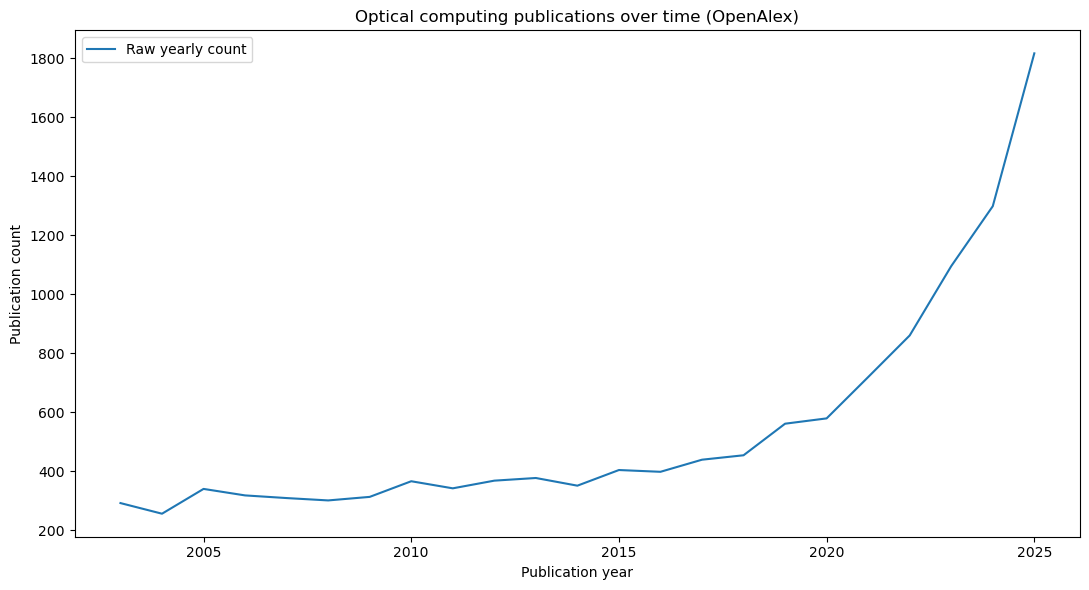

In [24]:
plot_time_series(
    df,
    rolling_window=ROLLING_WINDOW,
    plot_raw=PLOT_RAW,
    plot_rolling=PLOT_ROLLING,
)


In [ ]:
# Basic summary
df.describe()


In [12]:
# Inspect specific years
df[df["year"].between(2015, END_YEAR)]


,year,count_included_before_exclusion,count_excluded_matches,count_final


# Baseline - All Publications

In [7]:
import pandas as pd

# Load your previously saved optical dataset
combined = pd.read_csv("./Attempt2/1975-2025.csv")

display(combined.head())

,year,count_included_before_exclusion,count_excluded_matches,count_final,decade_source
0,1975,33,0,33,75-86
1,1976,47,0,47,75-86
2,1977,67,0,67,75-86
3,1978,71,0,71,75-86
4,1979,77,0,77,75-86


In [9]:
import requests
import time

START_YEAR = int(combined["year"].min())
END_YEAR = int(combined["year"].max())

def get_total_publications(year):
    params = {
        "filter": f"publication_year:{year}",
        "per-page": 1,
        "api_key": API_KEY,
    }

    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    return r.json()["meta"]["count"]

baseline_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"Fetching total publications for {year}...")

    try:
        count = get_total_publications(year)
    except Exception as e:
        print(f"Error for {year}: {e}")
        count = None

    baseline_rows.append({
        "year": year,
        "total_publications": count
    })

    time.sleep(0.3)

baseline_df = pd.DataFrame(baseline_rows)

display(baseline_df.head())

Fetching total publications for 1975...
Fetching total publications for 1976...
Fetching total publications for 1977...
Fetching total publications for 1978...
Fetching total publications for 1979...
Fetching total publications for 1980...
Fetching total publications for 1981...
Fetching total publications for 1982...
Fetching total publications for 1983...
Fetching total publications for 1984...
Fetching total publications for 1985...
Fetching total publications for 1986...
Fetching total publications for 1987...
Fetching total publications for 1988...
Fetching total publications for 1989...
Fetching total publications for 1990...
Fetching total publications for 1991...
Fetching total publications for 1992...
Fetching total publications for 1993...
Fetching total publications for 1994...
Fetching total publications for 1995...
Fetching total publications for 1996...
Fetching total publications for 1997...
Fetching total publications for 1998...
Fetching total publications for 1999...


,year,total_publications
0,1975,1100056
1,1976,1115567
2,1977,1159675
3,1978,1209648
4,1979,1256011


In [10]:
# Save baseline data
baseline_df.to_csv("baseline_all_publications.csv", index=False)
print("Saved: baseline_all_publications.csv")

Saved: baseline_all_publications.csv


## Basline EE/CS publications

In [22]:
import requests
import pandas as pd

def search_openalex_entity(entity, query, per_page=10):
    """
    entity: 'fields' or 'subfields'
    """
    url = f"https://api.openalex.org/{entity}"
    params = {
        "search": query,
        "per-page": per_page,
        "api_key": API_KEY,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["results"]

    rows = []
    for x in data:
        rows.append({
            "display_name": x.get("display_name"),
            "id": x.get("id"),
            "works_count": x.get("works_count"),
        })
    return pd.DataFrame(rows)

print("Fields matching 'computer science'")
display(search_openalex_entity("fields", "computer science", per_page=10))

print("Subfields matching 'electrical engineering'")
display(search_openalex_entity("subfields", "electrical engineering", per_page=10))

print("Subfields matching 'electronic engineering'")
display(search_openalex_entity("subfields", "electronic engineering", per_page=10))

Fields matching 'computer science'


,display_name,id,works_count
0,Computer Science,https://openalex.org/fields/17,23272223


Subfields matching 'electrical engineering'


,display_name,id,works_count
0,Electrical and Electronic Engineering,https://openalex.org/subfields/2208,10583147


Subfields matching 'electronic engineering'


,display_name,id,works_count
0,Electrical and Electronic Engineering,https://openalex.org/subfields/2208,10583147


In [23]:
COMPUTER_SCIENCE_FIELD_ID = "https://openalex.org/fields/17"
EE_SUBFIELD_ID = "https://openalex.org/subfields/2208"

In [24]:
START_YEAR = 1975
END_YEAR = 2025

SLEEP_BETWEEN_CALLS = 0.5
MAX_RETRIES = 8

def get_json_with_retry(url, params, timeout=30, max_retries=8):
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=timeout)

        if r.status_code == 429:
            wait = (2 ** attempt) + random.uniform(0, 1)
            print(f"[429] Sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        if r.status_code in (500, 502, 503, 504):
            wait = (2 ** attempt) + random.uniform(0, 1)
            print(f"[{r.status_code}] Sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        r.raise_for_status()
        return r.json()

    raise RuntimeError("Failed after retries")

def get_cs_ee_baseline_count(year, cs_field_id, ee_subfield_id):
    # OR syntax inside a single filter uses |
    # This means:
    # primary_topic.field.id == CS OR primary_topic.subfield.id == EE
    filter_str = (
        f"publication_year:{year},"
        f"primary_topic.field.id:{cs_field_id}|{ee_subfield_id}"
    )

    params = {
        "filter": filter_str,
        "per-page": 1,
        "api_key": API_KEY,
    }

    data = get_json_with_retry(BASE_URL, params=params, timeout=30, max_retries=MAX_RETRIES)
    return data["meta"]["count"]

rows = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"Fetching CS/EE baseline for {year}...")
    count = get_cs_ee_baseline_count(
        year,
        cs_field_id=COMPUTER_SCIENCE_FIELD_ID,
        ee_subfield_id=EE_SUBFIELD_ID,
    )
    rows.append({
        "year": year,
        "cs_ee_total_publications": count,
    })
    time.sleep(SLEEP_BETWEEN_CALLS)

baseline_cs_ee_df = pd.DataFrame(rows)
display(baseline_cs_ee_df.head())
display(baseline_cs_ee_df.tail())

Fetching CS/EE baseline for 1975...
Fetching CS/EE baseline for 1976...
Fetching CS/EE baseline for 1977...
Fetching CS/EE baseline for 1978...
Fetching CS/EE baseline for 1979...
Fetching CS/EE baseline for 1980...
Fetching CS/EE baseline for 1981...
Fetching CS/EE baseline for 1982...
Fetching CS/EE baseline for 1983...
Fetching CS/EE baseline for 1984...
Fetching CS/EE baseline for 1985...
Fetching CS/EE baseline for 1986...
Fetching CS/EE baseline for 1987...
Fetching CS/EE baseline for 1988...
Fetching CS/EE baseline for 1989...
Fetching CS/EE baseline for 1990...
Fetching CS/EE baseline for 1991...
Fetching CS/EE baseline for 1992...
Fetching CS/EE baseline for 1993...
Fetching CS/EE baseline for 1994...
Fetching CS/EE baseline for 1995...
Fetching CS/EE baseline for 1996...
Fetching CS/EE baseline for 1997...
Fetching CS/EE baseline for 1998...
Fetching CS/EE baseline for 1999...
Fetching CS/EE baseline for 2000...
Fetching CS/EE baseline for 2001...
Fetching CS/EE baseline for 

,year,cs_ee_total_publications
0,1975,24458
1,1976,24449
2,1977,26120
3,1978,27222
4,1979,28607


,year,cs_ee_total_publications
46,2021,638834
47,2022,613754
48,2023,687643
49,2024,710343
50,2025,808272


In [ ]:
baseline_cs_ee_df.to_csv(
    "./baseline_cs_ee_publications.csv",
    index=False
)
print("Saved: /baseline_cs_ee_publications.csv")

## EE Only Baseline

In [17]:
print(get_ee_baseline_count(2020, EE_FIELD_ID))

0


In [19]:
START_YEAR = 1975
END_YEAR = 2025

EE_SUBFIELD_ID = 2208   # Electrical and Electronic Engineering

SLEEP_BETWEEN_CALLS = 0.5
MAX_RETRIES = 8

def get_json_with_retry(url, params, timeout=30, max_retries=8):
    for attempt in range(max_retries):
        r = requests.get(url, params=params, timeout=timeout)

        if r.status_code == 429:
            wait = (2 ** attempt) + random.uniform(0, 1)
            print(f"[429] Sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        if r.status_code in (500, 502, 503, 504):
            wait = (2 ** attempt) + random.uniform(0, 1)
            print(f"[{r.status_code}] Sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        r.raise_for_status()
        return r.json()

    raise RuntimeError("Failed after retries")

def get_ee_baseline_count(year, ee_subfield_id):
    filter_str = (
        f"publication_year:{year},"
        f"primary_topic.subfield.id:{ee_subfield_id}"
    )

    params = {
        "filter": filter_str,
        "per-page": 1,
        "api_key": API_KEY,
    }

    data = get_json_with_retry(BASE_URL, params=params, timeout=30, max_retries=MAX_RETRIES)
    return data["meta"]["count"]


In [23]:
rows = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"Fetching EE baseline for {year}...")
    count = get_ee_baseline_count(year, EE_SUBFIELD_ID)
    rows.append({
        "year": year,
        "ee_total_publications": count,
    })
    time.sleep(SLEEP_BETWEEN_CALLS)

baseline_ee_df = pd.DataFrame(rows)
display(baseline_ee_df.head())
display(baseline_ee_df.tail())

Fetching EE baseline for 1975...
Fetching EE baseline for 1976...
Fetching EE baseline for 1977...
Fetching EE baseline for 1978...
Fetching EE baseline for 1979...
Fetching EE baseline for 1980...
Fetching EE baseline for 1981...
Fetching EE baseline for 1982...
Fetching EE baseline for 1983...
Fetching EE baseline for 1984...
Fetching EE baseline for 1985...
Fetching EE baseline for 1986...
Fetching EE baseline for 1987...
Fetching EE baseline for 1988...
Fetching EE baseline for 1989...
Fetching EE baseline for 1990...
Fetching EE baseline for 1991...
Fetching EE baseline for 1992...
Fetching EE baseline for 1993...
Fetching EE baseline for 1994...
Fetching EE baseline for 1995...
Fetching EE baseline for 1996...
Fetching EE baseline for 1997...
Fetching EE baseline for 1998...
Fetching EE baseline for 1999...
Fetching EE baseline for 2000...
Fetching EE baseline for 2001...
Fetching EE baseline for 2002...
Fetching EE baseline for 2003...
Fetching EE baseline for 2004...
Fetching E

,year,ee_total_publications
0,1975,16482
1,1976,16556
2,1977,17432
3,1978,18384
4,1979,19619


,year,ee_total_publications
46,2021,230590
47,2022,228555
48,2023,251644
49,2024,264506
50,2025,285793


In [24]:
baseline_ee_df.to_csv(
    "./baseline_ee_publications.csv",
    index=False
)
print("Saved: /baseline_ee_publications.csv")

Saved: /baseline_ee_publications.csv


## Optical Baseline

In [28]:
START_YEAR = 1975
END_YEAR = 2025

SLEEP_BETWEEN_CALLS = 0.5
MAX_RETRIES = 6

# -------------------------
# Optical baseline (clean)
# -------------------------
OPTICAL_SEARCH = (
    '"photonics" OR '
    '"photonic" OR '
    '"optical" OR '
    '"optics" OR '
    '"laser" OR '
    '"electro-optic" OR '
    '"optoelectronic"'
)

# Remove biomedical / imaging-heavy noise
OPTICAL_EXCLUDE = (
    '"optical coherence tomography" OR '
    '"microscopy" OR '
    '"biomedical optics" OR '
    '"ophthalmology" OR '
    '"retina" OR '
    '"endoscopy" OR '
    '"histology" OR '
    '"pathology"'
)

SEARCH_QUERY = f"({OPTICAL_SEARCH}) NOT ({OPTICAL_EXCLUDE})"

# =========================
# Robust request
# =========================
def get_json_with_retry(url, params, timeout=30, max_retries=6):
    for i in range(max_retries):
        r = requests.get(url, params=params, timeout=timeout)

        if r.status_code == 429:
            wait = (2 ** i) + random.random()
            print(f"[429] sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        r.raise_for_status()
        return r.json()

    raise RuntimeError("Too many retries")

# =========================
# Query function
# =========================
def get_optical_baseline(year):
    params = {
        "search": SEARCH_QUERY,
        "filter": f"publication_year:{year}",
        "per-page": 1,
        "api_key": API_KEY,
    }

    data = get_json_with_retry(BASE_URL, params)
    return data["meta"]["count"]

# =========================
# Run
# =========================
rows = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"{year}...")

    try:
        count = get_optical_baseline(year)
    except Exception as e:
        print("ERROR:", e)
        count = None

    rows.append({
        "year": year,
        "optical_total_publications": count
    })

    time.sleep(SLEEP_BETWEEN_CALLS)

baseline_optical_df = pd.DataFrame(rows)

# Save
baseline_optical_df.to_csv(
    "./baseline_optical_publications.csv",
    index=False
)

display(baseline_optical_df.head())
display(baseline_optical_df.tail())

1975...
1976...
1977...
1978...
1979...
1980...
1981...
1982...
1983...
1984...
1985...
1986...
1987...
1988...
1989...
1990...
1991...
1992...
1993...
1994...
1995...
1996...
1997...
1998...
1999...
2000...
2001...
2002...
2003...
2004...
2005...
2006...
2007...
2008...
2009...
2010...
2011...
2012...
2013...
2014...
2015...
2016...
2017...
2018...
2019...
2020...
2021...
2022...
2023...
2024...
2025...


,year,optical_total_publications
0,1975,15610
1,1976,16818
2,1977,18468
3,1978,19218
4,1979,19545


,year,optical_total_publications
46,2021,306481
47,2022,323170
48,2023,420556
49,2024,403178
50,2025,406342


## Optical Baseline again but only within the CS/EE subfield

In [31]:

START_YEAR = 1975
END_YEAR = 2025

SLEEP_BETWEEN_CALLS = 0.5
MAX_RETRIES = 6

CS_SUBFIELD_ID = "https://openalex.org/fields/17"
EE_SUBFIELD_ID = "https://openalex.org/subfields/2208"

# -------------------------
# Optical baseline (clean)
# -------------------------
OPTICAL_SEARCH = (
    '"photonics" OR '
    '"photonic" OR '
    '"optical" OR '
    '"optics" OR '
    '"laser" OR '
    '"electro-optic" OR '
    '"optoelectronic"'
)

OPTICAL_EXCLUDE = (
    '"optical coherence tomography" OR '
    '"microscopy" OR '
    '"biomedical optics" OR '
    '"ophthalmology" OR '
    '"retina" OR '
    '"endoscopy" OR '
    '"histology" OR '
    '"pathology"'
)

SEARCH_QUERY = f"({OPTICAL_SEARCH}) NOT ({OPTICAL_EXCLUDE})"

# =========================
# Robust request
# =========================
def get_json_with_retry(url, params, timeout=30, max_retries=6):
    for i in range(max_retries):
        r = requests.get(url, params=params, timeout=timeout)

        if r.status_code == 429:
            wait = (2 ** i) + random.random()
            print(f"[429] sleeping {wait:.1f}s")
            time.sleep(wait)
            continue

        if r.status_code == 401:
            raise ValueError("Invalid API key")

        r.raise_for_status()
        return r.json()

    raise RuntimeError("Too many retries")

# =========================
# Query function
# =========================
def get_optical_baseline_in_subfields(year):
    filter_str = (
        f"publication_year:{year},"
        f"primary_topic.subfield.id:{CS_SUBFIELD_ID}|{EE_SUBFIELD_ID}"
    )

    params = {
        "search": SEARCH_QUERY,
        "filter": filter_str,
        "per-page": 1,
        "api_key": API_KEY,
    }

    data = get_json_with_retry(BASE_URL, params)
    return data["meta"]["count"]

# =========================
# Run
# =========================
rows = []

for year in range(START_YEAR, END_YEAR + 1):
    print(f"{year}...")

    try:
        count = get_optical_baseline_in_subfields(year)
    except Exception as e:
        print("ERROR:", e)
        count = None

    rows.append({
        "year": year,
        "optical_cs_ee_subfield_publications": count
    })

    time.sleep(SLEEP_BETWEEN_CALLS)

baseline_optical_subfields_df = pd.DataFrame(rows)

baseline_optical_subfields_df.to_csv(
    "./baseline_optical_cs_ee_subfields.csv",
    index=False
)

display(baseline_optical_subfields_df.head())
display(baseline_optical_subfields_df.tail())


1975...
1976...
1977...
1978...
1979...
1980...
1981...
1982...
1983...
1984...
1985...
1986...
1987...
1988...
1989...
1990...
1991...
1992...
1993...
1994...
1995...
1996...
1997...
1998...
1999...
2000...
2001...
2002...
2003...
2004...
2005...
2006...
2007...
2008...
2009...
2010...
2011...
2012...
2013...
2014...
2015...
2016...
2017...
2018...
2019...
2020...
2021...
2022...
2023...
2024...
2025...


,year,optical_cs_ee_subfield_publications
0,1975,3464
1,1976,3657
2,1977,3697
3,1978,3841
4,1979,4335


,year,optical_cs_ee_subfield_publications
46,2021,36669
47,2022,37760
48,2023,45195
49,2024,45664
50,2025,45433
